# mjo_wavenum_freq_season

- "Calculates wavenumber-frequency spectra via seasonal averaging as defined by the US-CLIVAR MJO diagnostics website"
- [NCL Reference](https://www.ncl.ucar.edu/Document/Functions/Diagnostics/mjo_wavenum_freq_season.shtml)

### Example NCL Script and Output

- mjo_wavenum_freq_season.ncl
- mjo_output/mjo_wavenum_freq_season_output.txt

In [6]:
import os
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime

In [7]:
wavenum_freq = np.loadtxt("mjo_output/mjo_wavenum_freq_season_winter_ncl_output.txt", skiprows=18)
ncl_wavenum_freq = wavenum_freq.reshape(289, 181)
print(f"NCL Wavenumbers: {len(ncl_wavenum_freq)}")
print(f"NCL Frequencies: {len(ncl_wavenum_freq[0])}")

NCL Wavenumbers: 289
NCL Frequencies: 181


MJO CLIVAR: Wave number-frequency spectra
- "winter": 180 days (starts November 1)
- "summer": 180 days (starts May 1)
- "summer": 365 days (starts January 1)

In [8]:
u850_data = xr.open_dataset(os.getcwd() + "/data/anomaly/QBOi.EXP1.AMIP.001.u850.day.anom.nc")
u850_data

<xarray.Dataset> Size: 565MB
Dimensions:  (time: 2555, lat: 192, lon: 288)
Coordinates:
  * time     (time) object 20kB 1975-01-01 00:00:00 ... 1981-12-31 00:00:00
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.3 357.5 358.8
Data variables:
    date     (time) float64 20kB ...
    U850     (time, lat, lon) float32 565MB ...

In [9]:
# Filter out latitude and time ranges (based on NCL script)

## filter out latitude ranges
latS = -10
latN = 10

u850_data = u850_data.sel(lat=slice(latS, latN)) 

## filter out time ranges 
twStrt = "1979-01-01" # time window start
twLast = "1981-12-31" # time window end

u850_data = u850_data.sel(time=slice(twStrt, twLast)) 
u850_data

<xarray.Dataset> Size: 28MB
Dimensions:  (time: 1095, lat: 22, lon: 288)
Coordinates:
  * time     (time) object 9kB 1979-01-01 00:00:00 ... 1981-12-31 00:00:00
  * lat      (lat) float64 176B -9.895 -8.953 -8.01 -7.068 ... 8.01 8.953 9.895
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.3 357.5 358.8
Data variables:
    date     (time) float64 9kB ...
    U850     (time, lat, lon) float32 28MB ...

In [10]:
# Average data over latitude and use the averaged to compute spectra
## Compute the average of latitude

def dim_avg_n_wrap_python(data, dim):
    # https://www.ncl.ucar.edu/Document/Functions/Contributed/dim_avg_n_Wrap.shtml
    data = data.mean(dim=dim)
    return data

u850_data = dim_avg_n_wrap_python(u850_data, "lat")
u850_data

<xarray.Dataset> Size: 1MB
Dimensions:  (time: 1095, lon: 288)
Coordinates:
  * time     (time) object 9kB 1979-01-01 00:00:00 ... 1981-12-31 00:00:00
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.3 357.5 358.8
Data variables:
    date     (time) float64 9kB 1e+04 1e+04 1e+04 1e+04 ... 3e+04 3e+04 3e+04
    U850     (time, lon) float32 1MB -1.226 -1.366 -1.502 ... -0.8523 -0.9687

MJO wavenumber-frequency spectra based on Level 2 diagnostics- Based on [US-CLIVAR MJO Working Group (2009) "MJO Simulation Diagnostics - Level 2 diagnostics"](https://doi.org/10.1175/2008JCLI2731.1)

> "Level 2 diagnostics are designed to explore more detailed features of the MJO. They include wavenumber-frequency spectra of individual fields, cross-spectral quantities between different fields, and a multivariate EOF analysis. Wavenumber-frequency spectra for equatorial precipitation and 850-hPa zonal wind are shown in Fig. 7 for boreal summer, and in Fig. 8 for boreal winter.

> The spectra were computed by Fourier transforming 180-day segments centered on boreal summer and boreal winter, forming power, and then averaging over all years of data (1979–2005). The resulting bandwidth is (180 days)−1. Only the climatological season cycle was removed before calculation of the spectra.

> By definition, eastward propagation is represented by positive frequency and positive wavenumber whereas westward propagation is represented with one or the other of the frequency or wavenumber being negative. If standing oscillations are present, they will project as equal amounts of power in eastward and westward directions. The results indicate a concentration of power at 30–90-day periods and zonal wavenumber 1 for 850-hPa zonal wind, and zonal wavenumbers 1–3 for precipitation and OLR (e.g., Salby and Hendon 1994)"

In [11]:
def _taper(ts, alpha=0.1, iopt=0):
    # https://github.com/princekx/SEAPy_Climate/blob/ff48807c245978e85737cec778165c5faa7fc90b/src/diags_level2.py#L78
    if all(x == ts[0] for x in ts):
        print("all values are equal")
        iopt = 1
    if iopt == 0:
        tsmean = np.mean(ts)
    else:
        tsmean = 0.
    n = len(ts)
    m = max(1, int(alpha * n + 0.5) / 2)
    pim = np.pi / m

    tst = ts.copy()
    for i in range(1, int(m) + 1):
        weight = 0.5 - 0.5 * np.cos(pim * (i - 0.5))
        tst[i - 1] = (ts[i - 1] - tsmean) * weight + tsmean
        tst[n - i] = (ts[n - i] - tsmean) * weight + tsmean
    return tst

def resolveWavesHayashi(varfft, nDayWin, spd=1):
    # https://github.com/princekx/SEAPy_Climate/blob/ff48807c245978e85737cec778165c5faa7fc90b/src/diags_level2.py#L181
    N, mlon = varfft.shape
    pee = np.ones([N + 1, mlon + 1]) * -999
    varfft = np.abs(varfft) ** 2
    n_i = int(N / 2)
    mlon_i = int(mlon / 2)
    pee[ : n_i, : mlon_i] = varfft[n_i : N, mlon_i : 0:-1]
    pee[n_i : , : mlon_i ] = varfft[ : n_i + 1, mlon_i : 0 : -1]
    pee[ : n_i + 1, mlon_i : ] = varfft[ n_i : : -1, : mlon_i + 1]
    pee[n_i + 1 : , mlon_i : ] = varfft[N - 1: n_i - 1: -1 , : mlon_i + 1]
    return pee

In [14]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning) # supress FutureWarning

def mjo_wavenum_freq_season(input_data, season_name):
    # Based on SEAPy_climate: https://github.com/princekx/SEAPy_Climate/blob/ff48807c245978e85737cec778165c5faa7fc90b/src/diags_level2.py#L755
    # And NCL: https://github.com/NCAR/ncl/blob/8f9e9476281cc6f6d9d12eaa78729c7003ca24b7/ni/src/examples/gsun/diagnostics_cam.ncl#L2886
   
    season_name = season_name.lower()
    ntime = len(input_data.time)
    mlon = len(input_data.lon)
    
    time = input_data.time
    time = input_data.indexes["time"].to_datetimeindex(unsafe=True) # convert to datetime object (generates futurewarning)
    # convert YYYY-MM-DD to YYYYMMDD
    time = time.strftime("%Y%m%d")

    # Winter Start -- November 1 [180 days]
    # Summer Start -- May 1 [180 days]
    # Annual Start -- Jan 1 [365 days]
    if season_name == "winter":
        # November 1
        mmStart = 11
        ddStart = 1 
        nDay = 180
    if season_name == "summer":
        # May 1
        mmStart = 5
        ddStart = 1
        nDay = 180
    if season_name == "annual":
        # January 1
        mmStart = 1
        ddStart = 1
        nDay = 365

    print(f"{season_name}: starts on {mmStart}/{ddStart} for {nDay} days")

    # Collect start dates
    is_start_date_mask = (input_data["time.month"] == mmStart) & (input_data["time.day"] == ddStart)
    iSea = input_data.where(is_start_date_mask, drop=True) # places where it is start date
    iSea = iSea.time.values
    nYear = is_start_date_mask.sum(dim="time").item() # number of seasons
    print(f"Number of times start date {mmStart}/{ddStart} appears out of {len(input_data.time)} time steps (days) = {nYear}")

    #;*****************************************************************
    #; For a specific season, calculate spectra via averaging 
    #; over each seasonal segment.
    #; MJO Clivar says "no" to detrending/tapering.
    #; Hence, the following are just 'place holders'
    #;*****************************************************************
    
    # detrend overall series in time dimension
    ## dtrend_leftdim(x, False)
    lon_step_dx = (input_data.lon[1] - input_data.lon[0]).item() # longitude (degree step)
    poly_coeffs = input_data.polyfit(dim="time", deg=lon_step_dx, skipna=True)
    fit = xr.polyval(input_data["time"], poly_coeffs["date_polyfit_coefficients"])
    data_detrend = input_data - fit # remove linear trend

    # Initalize
    power = np.zeros([mlon + 1, nDay + 1])
    work = data_detrend["U850"].values
    xAvgSea = 0.0 # seasonal average over all time
    xVarSea = 0.0 # variance (raw)
    xVarTap = 0.0 # variance after tapering
    kSea = 0 # number of seasons

    for ny in range(nYear):
        print(f"Season Date: {iSea[ny]}")
        index_obj = input_data.time.to_index()

        # get index of starting and ending point
        iStrt = index_obj.get_loc(iSea[ny]) # start index for current season
        iLast = iStrt + nDay # last index for current season

        # only run FFT if end index is within time index
        if iLast < ntime - 1:
            xSeason = work[iStrt:iLast,:]
            xAvg = np.average(xSeason) # season average over all time and longitude
            xSeason -= xAvg # remove season mean from time-lon season
            xVarSea += np.var(xSeason) # overall variance (raw)
            kSea += 1 # increment count of the seasons

            # tapering
            for lon in range(mlon):
                taper = _taper(xSeason[:, lon])
                xSeason[:, lon] = taper

            # variance after tapering
            xVarTap += np.var(xSeason)

            # FFT
            FFT_2d = xSeason.copy()
            FFT_2d = np.fft.fft2(xSeason.T) / mlon / nDay

            # Shift FFT
            power += resolveWavesHayashi(FFT_2d, nDay, spd=1)  # (wave,freq)

    # pooled seasonal variance
    xVarSea /= kSea
    xVarTap /= kSea

    power = np.ma.masked_array(power / kSea) # pooled spectra
    wavenum = np.arange(-mlon / 2, mlon / 2 + 1, 1)
    freq = np.linspace(-1 * nDay / 2, nDay / 2, nDay + 1) / nDay

    return power, wavenum, freq

In [68]:
seasonName = "winter"
power, wavenum, freq = mjo_wavenum_freq_season(u850_data, seasonName)

print(f"\nDimensions and sizes: [wave | {len(wavenum)}] x [freq | {len(freq)}]")
print(f"Coordinates\n\twave:[{np.min(wavenum)} | {np.max(wavenum)}]\n\tfreq:[{np.min(freq)} | {np.max(freq)}]")

wavenum_xr = xr.DataArray(power,
                        coords = {"wavenum": wavenum, "freq": freq},
                        dims=("wavenum", "freq"),
                        name="power")
wavenum_xr

winter: starts on 11/1 for 180 days
Number of times start date 11/1 appears out of 1095 time steps (days) = 3
Season Date: 1979-11-01 00:00:00
Season Date: 1980-11-01 00:00:00
Season Date: 1981-11-01 00:00:00

Dimensions and sizes: [wave | 289] x [freq | 181]
Coordinates
	wave:[-144.0 | 144.0]
	freq:[-0.5 | 0.5]


<xarray.DataArray 'power' (wavenum: 289, freq: 181)> Size: 418kB
array([[1.99706793e-09, 7.40990726e-10, 8.20611550e-10, ...,
        8.20611550e-10, 7.40990726e-10, 1.99706793e-09],
       [6.31012042e-11, 1.32317578e-09, 8.98681978e-10, ...,
        7.73069853e-10, 1.30461378e-10, 6.31012042e-11],
       [2.18977041e-09, 7.32338998e-10, 7.06843676e-10, ...,
        1.03392682e-09, 1.63354059e-09, 2.18977041e-09],
       ...,
       [2.18977041e-09, 1.63354059e-09, 1.03392682e-09, ...,
        7.06843676e-10, 7.32338998e-10, 2.18977041e-09],
       [6.31012042e-11, 1.30461378e-10, 7.73069853e-10, ...,
        8.98681978e-10, 1.32317578e-09, 6.31012042e-11],
       [1.99706793e-09, 7.40990726e-10, 8.20611550e-10, ...,
        8.20611550e-10, 7.40990726e-10, 1.99706793e-09]], shape=(289, 181))
Coordinates:
  * wavenum  (wavenum) float64 2kB -144.0 -143.0 -142.0 ... 142.0 143.0 144.0
  * freq     (freq) float64 1kB -0.5 -0.4944 -0.4889 ... 0.4889 0.4944 0.5

### Compare outputs from NCL and Python

In [64]:
python_wavenum_freq = wavenum_xr.to_numpy().flatten()
python_wavenum_freq

array([1.99706793e-09, 7.40990726e-10, 8.20611550e-10, ...,
       8.20611550e-10, 7.40990726e-10, 1.99706793e-09], shape=(52309,))

In [65]:
# compare against NCL output
ncl_wavenum_freq = np.loadtxt(f"mjo_output/mjo_wavenum_freq_season_{seasonName}_ncl_output.txt", skiprows=18)
ncl_wavenum_freq

array([1.997126e-09, 7.409889e-10, 8.206045e-10, ..., 8.206045e-10,
       7.409889e-10, 1.997126e-09], shape=(52309,))

In [66]:
print(f"NCL    length = {len(ncl_wavenum_freq)}")
print(f"Python length = {len(python_wavenum_freq)}")

assert len(ncl_wavenum_freq) == len(python_wavenum_freq)

NCL    length = 52309
Python length = 52309


In [97]:
count_error = 0
for i in range(len(python_wavenum_freq)):
    tolerance = 0.000001
    try:
        diff = abs(ncl_wavenum_freq[i] - python_wavenum_freq[i])
        assert diff < tolerance
    except:
        #print(f"Index = {i}")
        #print(f"Difference = {diff}")
        #print(f"NCL    = {ncl_wavenum_freq[i]}")
        #print(f"Python = {python_wavenum_freq[i]}")
        count_error += 1
print(f"Number of values that are greater than tolerance ({tolerance}) = {count_error}")
print(f"{count_error} / {len(ncl_wavenum_freq)} = {100*(count_error/len(ncl_wavenum_freq)):0.5f}%")

Number of values that are greater than tolerance (1e-06) = 814
814 / 52309 = 1.55614%


# mjo_wavenum_freq_season_plot

- "Plot wavenumber-frequency spectra as returned by mjo_wavenum_freq_season"
- [NCL Reference](https://www.ncl.ucar.edu/Document/Functions/Diagnostics/mjo_wavenum_freq_season_plot.shtml)

### Example Plot fom `mjo_wavenum_freq_season.ncl`

- mjo_output/mjo_wavenum_freq_season_plot.winter.png

<center>
<img src="mjo_output/mjo_wavenum_freq_season_plot.winter.png" width="400" height="600">
</center>

In [88]:
# ncl
#wavenum_freq = np.loadtxt(f"mjo_output/mjo_wavenum_freq_season_{seasonName}_ncl_output.txt", skiprows=18)
#power_spectrum = wavenum_freq.reshape(289, 181)
#wavenum_xr = xr.DataArray(power_spectrum, 
#                          coords={"wavenum": power_spectrum[0], "freq": power_spectrum[1]},
#                          dims=("wavenum", "freq"))
wavenum_xr

<xarray.DataArray 'power' (wavenum: 289, freq: 181)> Size: 418kB
array([[1.99706793e-09, 7.40990726e-10, 8.20611550e-10, ...,
        8.20611550e-10, 7.40990726e-10, 1.99706793e-09],
       [6.31012042e-11, 1.32317578e-09, 8.98681978e-10, ...,
        7.73069853e-10, 1.30461378e-10, 6.31012042e-11],
       [2.18977041e-09, 7.32338998e-10, 7.06843676e-10, ...,
        1.03392682e-09, 1.63354059e-09, 2.18977041e-09],
       ...,
       [2.18977041e-09, 1.63354059e-09, 1.03392682e-09, ...,
        7.06843676e-10, 7.32338998e-10, 2.18977041e-09],
       [6.31012042e-11, 1.30461378e-10, 7.73069853e-10, ...,
        8.98681978e-10, 1.32317578e-09, 6.31012042e-11],
       [1.99706793e-09, 7.40990726e-10, 8.20611550e-10, ...,
        8.20611550e-10, 7.40990726e-10, 1.99706793e-09]], shape=(289, 181))
Coordinates:
  * wavenum  (wavenum) float64 2kB -144.0 -143.0 -142.0 ... 142.0 143.0 144.0
  * freq     (freq) float64 1kB -0.5 -0.4944 -0.4889 ... 0.4889 0.4944 0.5

In [67]:
import matplotlib.pyplot as plt
from cmap import Colormap

def mjo_wavenum_freq_season_plot_as_python(plt_title, wavenum_freq,
                                           max_wavenum=6,
                                           min_freq=-0.05, max_freq=0.05):
    fig, ax = plt.subplots(figsize=(6, 6))

    # Plot
    #print(wavenum_freq.values.min())
    #print(wavenum_freq.values.max())
    wavenum_freq = wavenum_freq.sel(freq=slice(min_freq, max_freq),
                                    wavenum=slice(0, max_wavenum))
    frequency = wavenum_freq.coords["freq"].values
    wavenumbers = wavenum_freq.coords["wavenum"].values

    wavenum, freq = np.meshgrid(frequency, wavenumbers)
    first_zero = np.where(frequency==0)[0][0] # first instance where frequency is zero
    wavenum_freq_power = wavenum_freq.copy()
    wavenum_freq_power.data[:,first_zero] = np.min(wavenum_freq_power.data) # 0th frequency

    #color_bar_data = plt.contourf(wavenum, freq, wavenum_freq_power.data, 
    #                              levels=np.arange(0, 3, 0.1),
    #                              extend="both")
    #plt.colorbar(color_bar_data)

    plt.ylim(0, max_wavenum)
    plt.xlim(min_freq, max_freq)

    # Line markers of periods and dates (30d and 80d)
    frqs = [80, 30]
    for day in frqs:
        plt.plot([1/ day, 1/ day], [-0, 15], 'k--', lw=0.5)
        plt.text(1/ day, 5.5, f"  {day}d", {'color' : 'k'})

    plt.title(plt_title)
    plt.ylabel('Zonal wavenumber')
    plt.xlabel("Frequency (westward -> eastward)")
    plt.show()
    
    
    '''
    wavenum_freq.plot.imshow()
    plt.contour(wavenum_freq,
                vmax=(wavenum_freq).max(), vmin=(wavenum_freq).min(),
                levels=10)
    plt.imshow(wavenum_freq, 
               vmax=(wavenum_freq).max(), vmin=(wavenum_freq).min(), 
               aspect="auto")
    '''
    
    #ax.set_xlim([min_freq, max_freq])
    #ax.set_ylim([0, max_wavenum])
    #ax.set_xlim([80, 100])
    #ax.set_ylim([140, 150])
    #plt.colorbar()
    ##plt.title(f"Wavenumber-Frequency: {plt_title}")
    ##plt.xlabel("Frequency (cycles/day)")
    ##plt.ylabel("Zonal Wavenumber (cycles/degree)")
    #plt.grid(True)
    #plt.show()

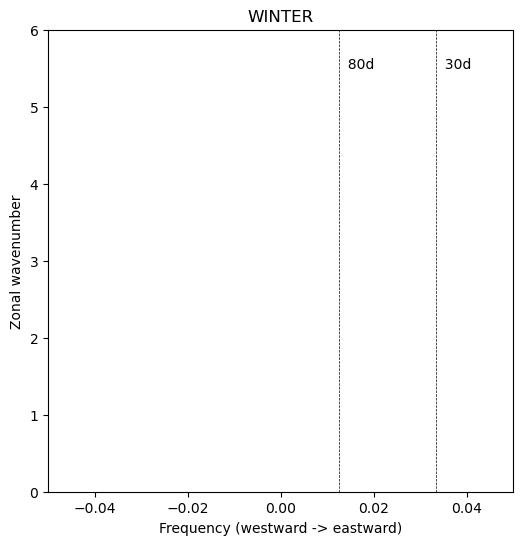

In [68]:
mjo_wavenum_freq_season_plot_as_python(f"{seasonName.upper()}", wavenum_xr)